# Benchmark: Set-distance metrics (e.g. hausdorff) for random point sets without optimization

In [2]:
import numpy as np
import pandas as pd
import plotnine as p9
from tqdm import tqdm, trange
import sys
import os
project_root = os.path.abspath('..')          # one level up from notebooks' directory
if project_root not in sys.path:
    sys.path.append(project_root)
from auction_module.bundling_and_bidding.fitness_functions.vrp_learn.distance import my_convex_hull_jaccard_distance, my_hausdorff_distance, my_MinWBMP, my_dice_similarity_coefficient, my_tsp_obj_val_diff, my_tsp_hull_jaccard_distance, my_modified_hausdorff_distance

In [8]:
rng = np.random.default_rng(1)

x_min, x_max, y_min, y_max = 0, 100, 0, 100
num_draws = 10000

records = []
for num_a in [8, 16]:
    for frac_b in [0.5, 1, 2]:
        num_b = int(num_a * frac_b)
        for draw in trange(num_draws, desc=f'{num_a} true vs. {num_b} predicted'):
            params = {
                'x_min': x_min,
                'x_max': x_max,
                'y_min': y_min,
                'y_max': y_max,
                'num_a': num_a,
                'num_b': num_b,
                'frac_b': frac_b 
            }
            set_a = rng.uniform((x_min, y_min), (x_max, y_max), size=(num_a, 2))
            set_b = rng.uniform((x_min, y_min), (x_max, y_max), size=(num_b, 2))
            df = pd.DataFrame(np.concat([set_a, set_b], axis=0), columns=['x', 'y'])
            # df['label'] = ["a"] * num_a + ["b"] * num_b
            # p9.qplot('x', 'y', df, geom='point', fill='label', size=4)
            metrics = {
                'hausdorff': my_hausdorff_distance(set_a, set_b),
                'modified hausdorff': my_modified_hausdorff_distance(set_a, set_b),
                'jaccard': my_convex_hull_jaccard_distance(set_a, set_b),
                # 'MinWBMP': my_MinWBMP(set_a, set_b),
                # 'dice': my_dice_similarity_coefficient(set_a, set_b),
                # 'TSP objective': my_tsp_obj_val_diff(set_a, set_b),
                # 'TSP hull': my_tsp_hull_jaccard_distance(set_a, set_b)
            }
            metrics['normalized hausdorff'] = metrics['hausdorff']/np.sqrt((x_max-x_min)**2 + (y_max - y_min)**2)
            metrics['normalized modified hausdorff'] = metrics['modified hausdorff']/np.sqrt((x_max-x_min)**2 + (y_max - y_min)**2)
            record = {**metrics, **params}
            records.append(record)
df = pd.DataFrame.from_records(records)
df

16 true vs. 32 predicted: 100%|██████████| 10000/10000 [00:01<00:00, 5493.86it/s]


,hausdorff,modified hausdorff,jaccard,normalized hausdorff,normalized modified hausdorff,x_min,x_max,y_min,y_max,num_a,num_b,frac_b
0,34.253761,21.455268,0.494321,0.242211,0.151712,0,100,0,100,8,4,0.5
1,52.200926,22.329882,0.795275,0.369116,0.157896,0,100,0,100,8,4,0.5
2,49.091508,25.811843,0.476296,0.347129,0.182517,0,100,0,100,8,4,0.5
3,71.981463,29.277483,0.983331,0.508986,0.207023,0,100,0,100,8,4,0.5
4,36.764999,20.798937,0.761962,0.259968,0.147071,0,100,0,100,8,4,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...
59995,24.314649,10.726005,0.240106,0.171931,0.075844,0,100,0,100,16,32,2.0
59996,31.604892,11.635948,0.194292,0.223480,0.082279,0,100,0,100,16,32,2.0
59997,29.164809,14.475035,0.293702,0.206226,0.102354,0,100,0,100,16,32,2.0
59998,33.695102,13.553143,0.369605,0.238260,0.095835,0,100,0,100,16,32,2.0


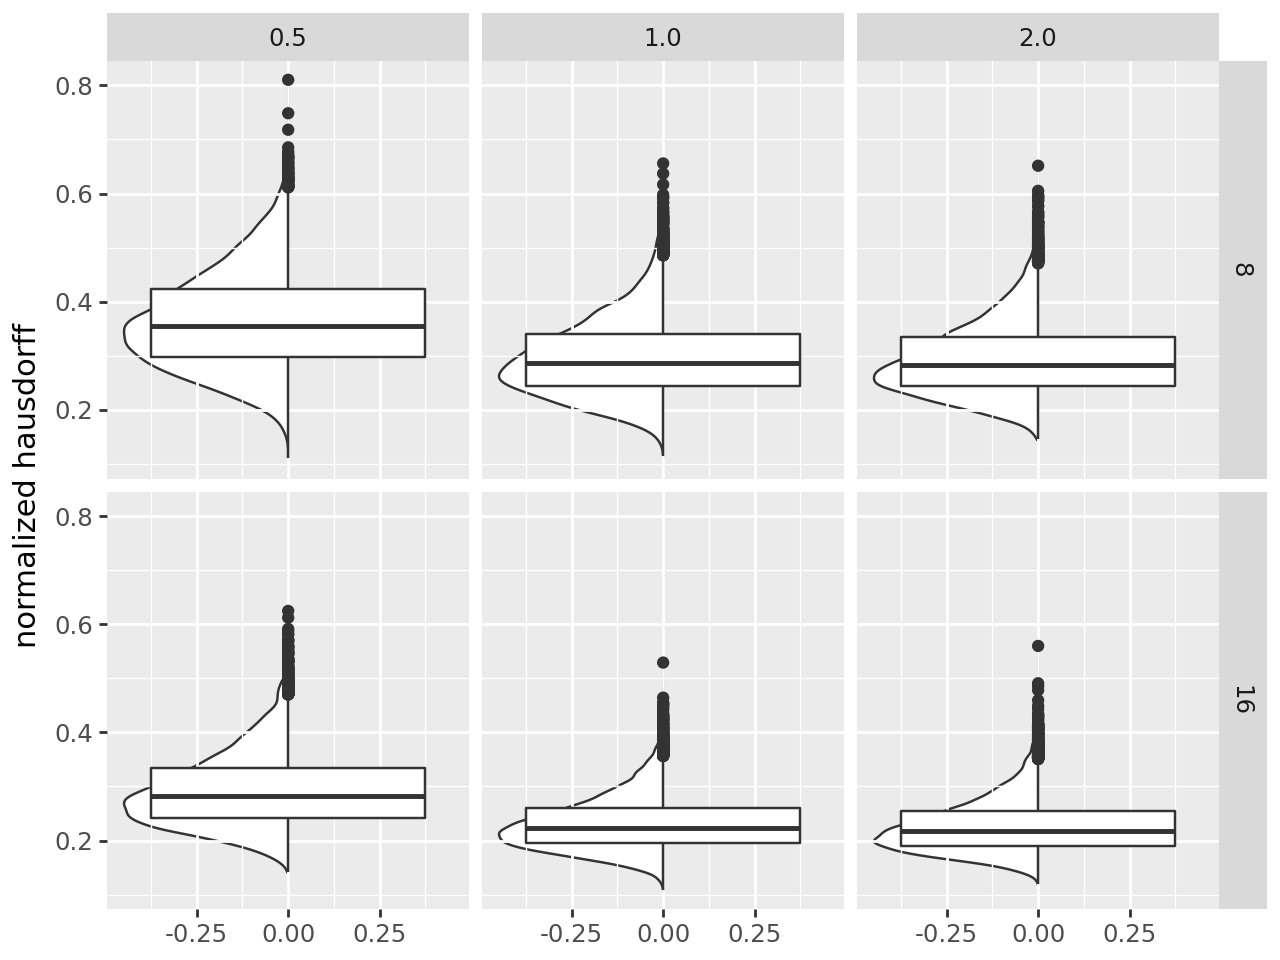

In [9]:
(p9.ggplot( df, p9.aes(y='normalized hausdorff'))
+ p9.geom_violin(style='left')
+ p9.geom_boxplot()
+ p9.facet_grid('num_a', 'frac_b')
)

In [10]:
df.groupby(['frac_b', 'num_a']).describe()['normalized hausdorff']

count      mean       std       min       25%       50%  \
frac_b num_a                                                              
0.5    8      10000.0  0.364520  0.090770  0.110892  0.297479  0.355386   
       16     10000.0  0.292843  0.068648  0.141787  0.242253  0.282276   
1.0    8      10000.0  0.296029  0.072845  0.113836  0.243079  0.286906   
       16     10000.0  0.231057  0.050246  0.107623  0.194740  0.223642   
2.0    8      10000.0  0.293410  0.068744  0.145459  0.243574  0.282316   
       16     10000.0  0.226823  0.049686  0.119862  0.190687  0.218436   

                   75%       max  
frac_b num_a                      
0.5    8      0.423050  0.810384  
       16     0.333327  0.624664  
1.0    8      0.339969  0.655706  
       16     0.259324  0.529119  
2.0    8      0.334542  0.651423  
       16     0.254632  0.559918